In [1]:
from astropy.io import votable
from astropy import constants as const
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
wray_SED_vot = votable.parse('wray_sed.vot')
table = wray_SED_vot.get_first_table()
wray_SED_table = table.to_table()
wray_SED_table_f = wray_SED_table['sed_freq', 'sed_flux', 'sed_eflux']
wray_SED_table_f.rename_columns(['sed_freq', 'sed_flux', 'sed_eflux'], ['sed_freq_GHz', 'sed_flux_Jy', 'sed_eflux_Jy'])

frequency_Hz = wray_SED_table_f['sed_freq_GHz'] * 1e9

# Calculate wavelength in meters: λ = c / ν
wavelength_m = const.c.value / frequency_Hz

# Convert meters to micrometers (μm) by multiplying by 1e6
wavelength_um = wavelength_m * 1e6

# Round to 3 significant figures and add as a new column
# The '%.3g' formatter handles significant figures correctly (e.g., 123.4, 12.3, 1.23, 0.123)
wray_SED_table_f['sed_wl_um'] = np.array([float('%.3g' % x) for x in wavelength_um])

# 4. (Optional) Reorder columns if desired. Let's put wavelength first.
# This creates a new table with the columns in this specific order.
final_table =wray_SED_table_f['sed_wl_um', 'sed_freq_GHz', 'sed_flux_Jy', 'sed_eflux_Jy']

final_table.write('wray_sed.csv', format='ascii.csv', overwrite=True)

Here we remove the duplicates and put the wavelengths in ascending order:

In [3]:
# Read the CSV file
df = pd.read_csv('wray_sed.csv')

# Sort by the 'sed_wl_um' column in ascending order
df_sorted = df.sort_values(by='sed_wl_um', ascending=True)

# Check how many rows you have before removing duplicates
print(f"Original number of rows: {len(df_sorted)}")

# Remove duplicate rows (keeps the first occurrence by default)
df_clean = df_sorted.drop_duplicates()

# Check how many rows remain
print(f"Number of rows after removing duplicates: {len(df_clean)}")
print(f"Number of duplicates removed: {len(df_sorted) - len(df_clean)}")

rows_to_remove = [105, 117, 120, 81, 80, 67, 72, 60, 61, 62, 63, 49, 44, 41]
df_clean = df_clean.iloc[[i for i in range(len(df_clean)) if i not in rows_to_remove]]

# Save the cleaned dataframe back to CSV
df_clean.to_csv('wray_sed_clean.csv', index=False)

print("Cleaned file saved as 'wray_sed_clean.csv'")

Original number of rows: 246
Number of rows after removing duplicates: 123
Number of duplicates removed: 123
Cleaned file saved as 'wray_sed_clean.csv'


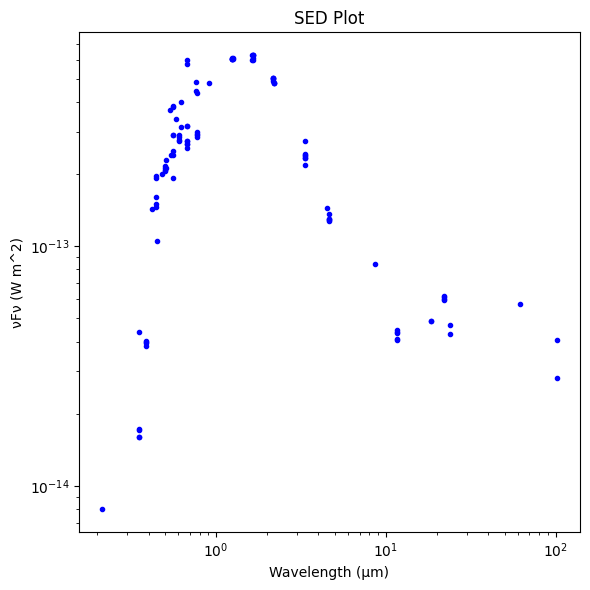

In [4]:
data = pd.read_csv('wray_sed_clean.csv')

v_fv = np.array(data['sed_freq_GHz'] * data['sed_flux_Jy'] * 1e-17)
wl = np.array(data['sed_wl_um'])
v_fv_err = data['sed_freq_GHz'] * data['sed_eflux_Jy'] * 1e-17

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(wl, v_fv, 'bo', markersize=3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('νFν (W m^2)')
ax.set_title('SED Plot')

plt.tight_layout()
plt.show()

In [5]:
len(v_fv)

109